[[85  5]
 [ 5 48]]
[[89  1]
 [ 5 48]]
Plot saved as svm_plot.png


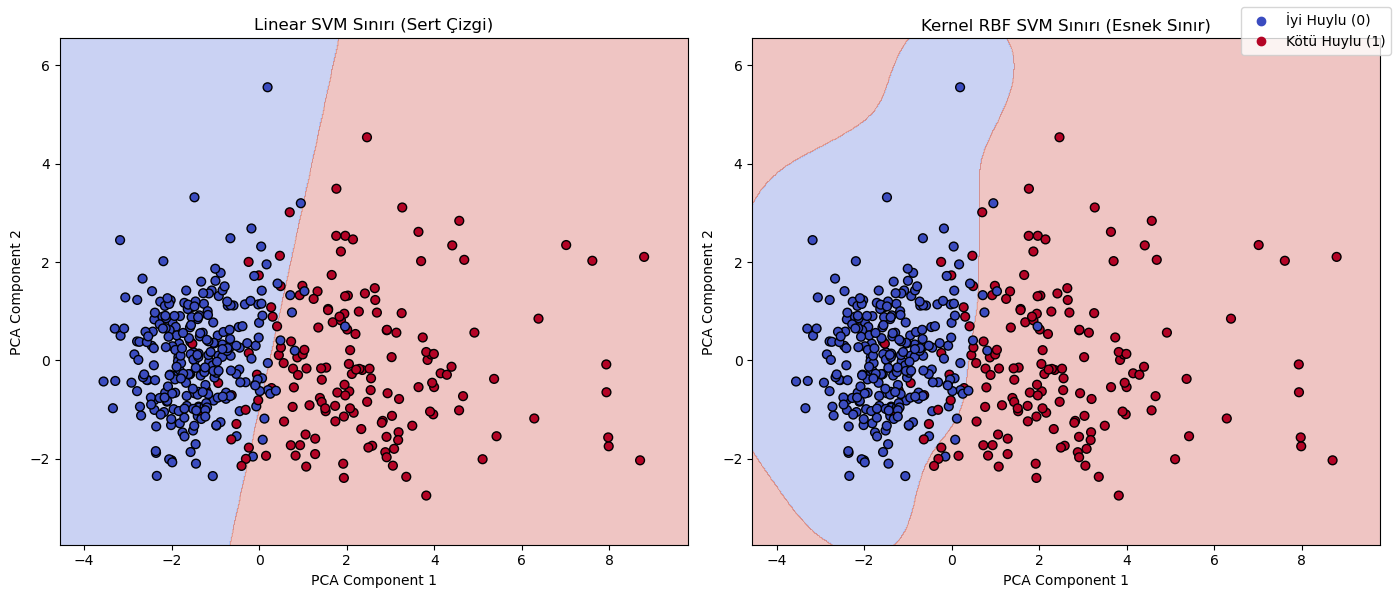

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import io
import base64

# Veriyi yükle
df = pd.read_csv("breast-cancer-selected-columns.csv")

# Hedef değişkeni ayarla (M = Malignant = 1, B = Benign = 0)
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop(columns=['id', 'diagnosis', 'target'])
y = df['target']

# Eğitim ve test seti
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeller
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

cm = confusion_matrix(y_test,y_pred_linear)
print(cm)

svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

cm = confusion_matrix(y_test,y_pred_rbf)
print(cm)


# PCA ile Görselleştirme
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

model_lin_2d = SVC(kernel='linear').fit(X_train_pca, y_train)
model_rbf_2d = SVC(kernel='rbf', gamma=0.5, C=1.0).fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ['Linear SVM Sınırı (Sert Çizgi)', 'Kernel RBF SVM Sınırı (Esnek Sınır)']
models_2d = [model_lin_2d, model_rbf_2d]

for ax, model, title in zip(axes, models_2d, titles):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=40)
    ax.set_title(title)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

handles, _ = scatter.legend_elements()
fig.legend(handles, ['İyi Huylu (0)', 'Kötü Huylu (1)'], loc='upper right')
plt.tight_layout()

# Save plot to display
plt.savefig("svm_plot.png")
print("Plot saved as svm_plot.png")